# 该脚本用于删除到时数量少于指定阈值的地震

当到时数较少时，地震位置与发震时刻难以准确约束。

为了降低震源不确定性的影响，可以选择删除这些地震

如果对震源位置可靠性有信心，可以忽略该步骤

In [1]:
# 载入 TomoATT 数据处理函数
import sys
sys.path.append('./utils')
import functions_for_data as ffd

# 1. 读取到时数据文件

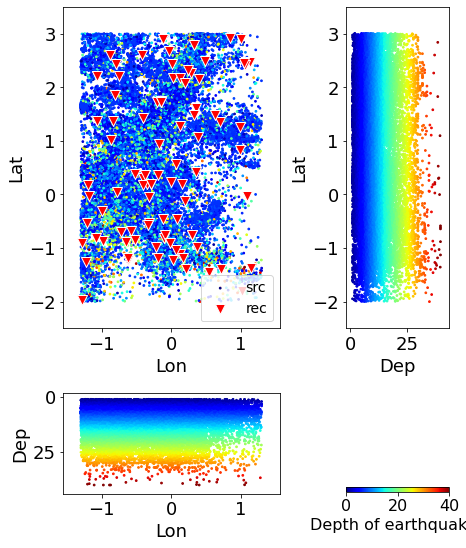

In [2]:
# 读取数据
fname = "output_data/step2_src_rec_remove_outlier.dat"
[ev_info_obs, st_info_obs] = ffd.read_src_rec_file(fname)

# 数据画图（可选） fname = None 可以不保存图片
ffd.fig_ev_st_distribution_dep(ev_info_obs, st_info_obs, fname = None)

# 2. 删除到时数量较少的地震

Original data set has 64781 earthquakes, 44252 earthquakes are deleted, 20529 earthquakes are retained


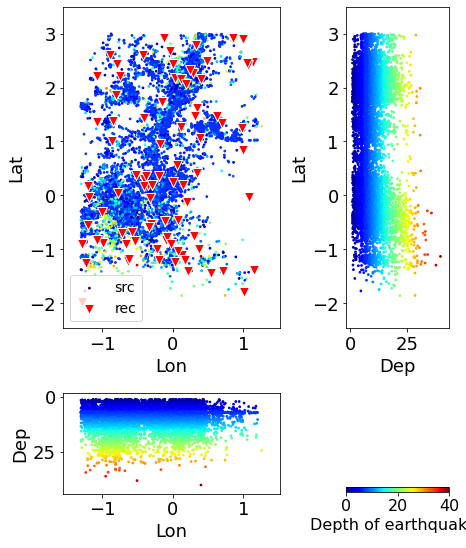

In [3]:
# 到时数量阈值设置为 5
min_Nt_thd = 5
ev_filtered = ffd.limit_min_Nt(min_Nt_thd, ev_info_obs)

# 数据画图（可选） fname = None 可以不保存图片
ffd.fig_ev_st_distribution_dep(ev_filtered, st_info_obs, fname = None)

# 3. 数据输出

In [4]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = "%s/step3_src_rec_filtered.dat"%(out_path)
ffd.write_src_rec_file(out_fname,ev_filtered,st_info_obs)

src_rec.dat has been outputed: 20529 events, 92 stations, 152254 abs traveltime, 0 cs_dif traveltime, 0 cr_dif traveltime. 
earthquake and station region, lat:   -2.0 -    3.0, lon:   -1.3 -    1.3, dep:   -1.9 -   40.0
